In [ ]:
import os
import sys
import shutil
import glob

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")

    # Mount Drive
    drive.mount('/content/drive')

    # Clone Repository
    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists('/content/code'):
        print(f"Cloning repository from {REPO_URL}...")
        !git clone --recursive {REPO_URL} /content/code
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
    else:
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
        !git pull origin {BRANCH}

    os.chdir('/content/code')
    if '/content/code' not in sys.path:
        sys.path.append('/content/code')

    # Install requirements
    !pip install -q torcheval loguru scipy

    # --- EXTRACT OMNIVORE FROM 1s.zip (like train_lstm_baseline) ---
    DRIVE_BASE = "/content/drive/MyDrive/AML_Project"
    data_zip = f"{DRIVE_BASE}/1s.zip"

    # Check if Omnivore extraction is needed
    omnivore_target = "data/video/omnivore"
    if not os.path.exists(omnivore_target) or len(os.listdir(omnivore_target)) == 0:
        if os.path.exists(data_zip):
            print(f"Found 1s.zip at: {data_zip}")

            # Extract 1s.zip
            print("Extracting 1s.zip...")
            !mkdir -p data
            !unzip -q -n "{data_zip}" -d data

            # Extract Nested Omnivore Zip
            nested_zip = "data/1s/video/omnivore.zip"
            if os.path.exists(nested_zip):
                print(f"Extracting nested omnivore.zip...")
                !mkdir -p {omnivore_target}

                # Extract to temp dir
                temp_extract = "data/temp_omnivore"
                !unzip -q -n "{nested_zip}" -d {temp_extract}

                # Move files to target
                files = glob.glob(f"{temp_extract}/**/*.npz", recursive=True)
                for f in files:
                    shutil.move(f, omnivore_target)
                print(f"Moved {len(files)} Omnivore files to {omnivore_target}")

                # Cleanup
                !rm -rf {temp_extract}
            else:
                print(f"WARNING: {nested_zip} not found")

            # Cleanup 1s folder
            if os.path.exists("data/1s"):
                !rm -rf data/1s

            print(f"Omnivore setup complete: {len(os.listdir(omnivore_target))} files")
        else:
            print(f"WARNING: 1s.zip not found at {data_zip}")
    else:
        print(f"Omnivore already extracted: {len(os.listdir(omnivore_target))} files")

except ImportError:
    IN_COLAB = False
    print("Not running in Colab")

Running in Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
From https://github.com/zeynepoztunc/aml-procedural-mistake-detection
 * branch            emre-second-step -> FETCH_HEAD
Already on 'emre-second-step'
Your branch is up to date with 'origin/emre-second-step'.
From https://github.com/zeynepoztunc/aml-procedural-mistake-detection
 * branch            emre-second-step -> FETCH_HEAD
Already up to date.


In [ ]:
import json
import numpy as np
import torch
import os
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

# Configuration - CORRECT PATHS
if IN_COLAB:
    DRIVE_BASE = "/content/drive/MyDrive/AML_Project"
    # EgoVLP: directly from Drive (already extracted)
    EGOVLP_FEATURE_DIR = os.path.join(DRIVE_BASE, "features/egovlp")
    # Omnivore: extracted locally from 1s.zip (done in setup cell)
    OMNIVORE_FEATURE_DIR = "data/video/omnivore"
else:
    # Local paths
    EGOVLP_FEATURE_DIR = "data/features/egovlp"
    OMNIVORE_FEATURE_DIR = "data/video/omnivore"

# Which features to use (set to 'egovlp' or 'omnivore')
USE_BACKBONE = "egovlp"  # Using EgoVLP (256-dim) - change to "omnivore" for 1024-dim

ANNOTATION_PATH = "annotations/annotation_json/step_annotations.json"
ERROR_ANNOTATION_PATH = "annotations/annotation_json/error_annotations.json"
SPLIT_PATH = "er_annotations/recordings_combined_splits.json"

print(f"Using backbone: {USE_BACKBONE}")
print(f"EgoVLP features: {EGOVLP_FEATURE_DIR}")
print(f"Omnivore features: {OMNIVORE_FEATURE_DIR}")
print(f"Annotation path: {ANNOTATION_PATH}")

# Verify feature directories
if IN_COLAB:
    if os.path.exists(EGOVLP_FEATURE_DIR):
        print(f"✓ EgoVLP: {len(os.listdir(EGOVLP_FEATURE_DIR))} files")
    else:
        print(f"✗ EgoVLP directory not found")
    
    if os.path.exists(OMNIVORE_FEATURE_DIR):
        print(f"✓ Omnivore: {len(os.listdir(OMNIVORE_FEATURE_DIR))} files")
    else:
        print(f"✗ Omnivore directory not found")

Using backbone: egovlp
EgoVLP features: /content/drive/MyDrive/AML_Project/features/egovlp
Omnivore features: /content/drive/MyDrive/AML_Project/features/omnivore
Annotation path: annotations/annotation_json/step_annotations.json


## 1. Load Annotations

Load step annotations (ground truth boundaries) and error annotations for recipe-level labels.

In [16]:
# Load step annotations
with open(ANNOTATION_PATH, 'r') as f:
    step_annotations = json.load(f)

# Load error annotations
with open(ERROR_ANNOTATION_PATH, 'r') as f:
    error_annotations = json.load(f)

# Load train/val/test splits
with open(SPLIT_PATH, 'r') as f:
    splits = json.load(f)

print(f"Total recordings: {len(step_annotations)}")
print(f"Train: {len(splits['train'])}, Val: {len(splits['val'])}, Test: {len(splits['test'])}")

# Sample annotation structure
sample_recording = list(step_annotations.keys())[0]
print(f"\nSample recording: {sample_recording}")
print(f"Keys: {step_annotations[sample_recording].keys()}")

Total recordings: 384
Train: 287, Val: 48, Test: 48

Sample recording: 1_7
Keys: dict_keys(['recording_id', 'steps'])


In [17]:
# Create a mapping from recording_id to recipe-level label
# Recipe is incorrect if ANY step has errors

recording_error_labels = {}
recording_error_details = defaultdict(list)

for error_record in error_annotations:
    recording_id = error_record['recording_id']
    has_recipe_error = False

    for step_ann in error_record['step_annotations']:
        if 'errors' in step_ann and len(step_ann['errors']) > 0:
            has_recipe_error = True
            recording_error_details[recording_id].append({
                'step_id': step_ann['step_id'],
                'errors': step_ann['errors']
            })

    recording_error_labels[recording_id] = 1 if has_recipe_error else 0

# Statistics
total_correct = sum(1 for v in recording_error_labels.values() if v == 0)
total_incorrect = sum(1 for v in recording_error_labels.values() if v == 1)

print(f"Total recordings with labels: {len(recording_error_labels)}")
print(f"Correct executions: {total_correct} ({100*total_correct/len(recording_error_labels):.1f}%)")
print(f"Incorrect executions: {total_incorrect} ({100*total_incorrect/len(recording_error_labels):.1f}%)")

Total recordings with labels: 384
Correct executions: 164 (42.7%)
Incorrect executions: 220 (57.3%)


## 2. Ground Truth Step Localization

Extract step boundaries from ground truth annotations.
For each step, we get (start_time, end_time) tuples.

In [18]:
def get_step_boundaries_gt(recording_id, annotations):
    """
    Get ground truth step boundaries for a recording.

    Returns:
        list of dicts: [{step_id, start_time, end_time, step_description}, ...]
    """
    if recording_id not in annotations:
        return []

    steps = annotations[recording_id].get('steps', [])
    boundaries = []

    for step in steps:
        start_time = step.get('start_time', -1)
        end_time = step.get('end_time', -1)

        # Skip invalid steps
        if start_time < 0 or end_time < 0 or end_time <= start_time:
            continue

        boundaries.append({
            'step_id': step.get('step_id'),
            'start_time': start_time,
            'end_time': end_time,
            'description': step.get('description', ''),
            'has_errors': step.get('has_errors', False)
        })

    # Sort by start time
    boundaries.sort(key=lambda x: x['start_time'])
    return boundaries

# Test on a sample recording
sample_boundaries = get_step_boundaries_gt(sample_recording, step_annotations)
print(f"Recording {sample_recording} has {len(sample_boundaries)} steps:")
for i, step in enumerate(sample_boundaries[:5]):
    print(f"  Step {i+1}: {step['start_time']:.1f}s - {step['end_time']:.1f}s | {step['description'][:50]}...")

Recording 1_7 has 12 steps:
  Step 1: 7.1s - 46.3s | Coat -Coat a 6-oz. ramekin cup with cooking spray...
  Step 2: 50.3s - 82.3s | Pour-Pour 1 egg into the ramekin cup...
  Step 3: 92.6s - 135.3s | Microwave-Microwave the ramekin cup uncovered on h...
  Step 4: 136.0s - 185.5s | Cut -Cut the English muffin into two pieces with a...
  Step 5: 197.3s - 224.7s | stir-stir the ramekin cup...


## 3. Compute Step-Level Embeddings

For each step, average all sub-segment features within the step boundaries.

**Note**: Features are typically extracted at 1-second or 2-second intervals.
We average features that fall within [start_time, end_time] of each step.

In [19]:
def load_video_features(recording_id, backbone='omnivore'):
    """
    Load pre-extracted features for a video.

    Args:
        recording_id: The recording ID (e.g., '10_16')
        backbone: 'omnivore' or 'egovlp'

    Returns:
        features: np.array of shape (num_segments, feature_dim)
        segment_duration: float (seconds per segment)
    """
    if backbone == 'egovlp':
        feature_dir = EGOVLP_FEATURE_DIR
        # EgoVLP files are named: {recording_id}_360p_224.npz or {recording_id}.npz
        possible_patterns = [
            f"{recording_id}_360p_224.npz",
            f"{recording_id}.npz",
        ]
        feature_key = 'video_features'
        segment_duration = 2.0  # EgoVLP uses 2-second segments
    else:  # omnivore
        feature_dir = OMNIVORE_FEATURE_DIR
        # Omnivore files are named: {recording_id}_360p.mp4_1s_1s.npz
        possible_patterns = [
            f"{recording_id}_360p.mp4_1s_1s.npz",
            f"{recording_id}.npz",
        ]
        feature_key = 'arr_0'
        segment_duration = 1.0  # Omnivore uses 1-second segments

    # Try to find the feature file
    feature_path = None
    for pattern in possible_patterns:
        path = os.path.join(feature_dir, pattern)
        if os.path.exists(path):
            feature_path = path
            break

    # If still not found, search for files starting with recording_id
    if feature_path is None and os.path.exists(feature_dir):
        for f in os.listdir(feature_dir):
            if f.startswith(recording_id) and f.endswith('.npz'):
                feature_path = os.path.join(feature_dir, f)
                break

    if feature_path is None or not os.path.exists(feature_path):
        return None, None

    try:
        data = np.load(feature_path)

        # Get features using the correct key
        if feature_key in data:
            features = data[feature_key]
        elif 'features' in data:
            features = data['features']
        elif 'arr_0' in data:
            features = data['arr_0']
        else:
            # Use first available key
            features = data[list(data.keys())[0]]

        # Handle NaN values
        features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)

        return features, segment_duration
    except Exception as e:
        print(f"Error loading {feature_path}: {e}")
        return None, None


def compute_step_embeddings(recording_id, step_boundaries, backbone='omnivore'):
    """
    Compute step-level embeddings by averaging features within each step boundary.

    Returns:
        step_embeddings: np.array of shape (num_steps, feature_dim)
        step_info: list of step metadata
    """
    features, seg_duration = load_video_features(recording_id, backbone)

    if features is None:
        return None, None

    num_segments, feature_dim = features.shape
    step_embeddings = []
    step_info = []

    for step in step_boundaries:
        start_time = step['start_time']
        end_time = step['end_time']

        # Find segment indices within this step
        start_idx = int(start_time / seg_duration)
        end_idx = int(end_time / seg_duration)

        # Clip to valid range
        start_idx = max(0, start_idx)
        end_idx = min(num_segments, end_idx + 1)

        if end_idx <= start_idx:
            # If no features in this range, use the nearest segment
            nearest_idx = min(start_idx, num_segments - 1)
            step_embedding = features[nearest_idx]
        else:
            # Average features in this step
            step_embedding = features[start_idx:end_idx].mean(axis=0)

        step_embeddings.append(step_embedding)
        step_info.append(step)

    if len(step_embeddings) == 0:
        return None, None

    return np.stack(step_embeddings), step_info


# Test feature loading
print("Testing feature loading...")

# Find a sample recording to test
sample_recording = list(step_annotations.keys())[0]
print(f"\nTesting with recording: {sample_recording}")

# Test Omnivore
omni_feat, omni_seg = load_video_features(sample_recording, 'omnivore')
if omni_feat is not None:
    print(f"✓ Omnivore: shape={omni_feat.shape}, seg_duration={omni_seg}s")
else:
    print("✗ Omnivore: NOT FOUND")

# Test EgoVLP
ego_feat, ego_seg = load_video_features(sample_recording, 'egovlp')
if ego_feat is not None:
    print(f"✓ EgoVLP: shape={ego_feat.shape}, seg_duration={ego_seg}s")
else:
    print("✗ EgoVLP: NOT FOUND")

# Test step embedding computation
sample_boundaries = get_step_boundaries_gt(sample_recording, step_annotations)
step_emb, step_info = compute_step_embeddings(sample_recording, sample_boundaries, USE_BACKBONE)

if step_emb is not None:
    print(f"\n✓ Step embeddings shape: {step_emb.shape}")
    print(f"  Number of steps: {len(step_info)}")
else:
    print("\n✗ Failed to compute step embeddings")

Testing feature loading...

Testing with recording: 1_7
✗ Omnivore: NOT FOUND
✓ EgoVLP: shape=(301, 256), seg_duration=2.0s

✓ Step embeddings shape: (12, 256)
  Number of steps: 12


## 4. Process All Recordings

Generate step-level embeddings for all recordings in the dataset.

In [ ]:
def process_all_recordings(recording_ids, annotations, backbone='omnivore'):
    """
    Process all recordings to get step-level embeddings and recipe-level labels.

    Returns:
        data: dict with recording_id -> {
            'step_embeddings': np.array,
            'step_info': list,
            'recipe_label': int (0=correct, 1=incorrect),
            'recipe_id': str
        }
    """
    data = {}
    missing_features = []
    missing_annotations = []

    for recording_id in tqdm(recording_ids, desc="Processing recordings"):
        # Get step boundaries
        boundaries = get_step_boundaries_gt(recording_id, annotations)

        if len(boundaries) == 0:
            missing_annotations.append(recording_id)
            continue

        # Compute step embeddings using specified backbone
        step_emb, step_info = compute_step_embeddings(recording_id, boundaries, backbone)

        if step_emb is None:
            missing_features.append(recording_id)
            continue

        # Get recipe-level label
        recipe_label = recording_error_labels.get(recording_id, 0)

        # Get recipe/activity ID from recording_id prefix
        # Format: "{activity_id}_{recording_num}" (e.g., "1_7" = activity 1, recording 7)
        recipe_id = recording_id.split('_')[0] if '_' in recording_id else 'unknown'

        data[recording_id] = {
            'step_embeddings': step_emb,
            'step_info': step_info,
            'recipe_label': recipe_label,
            'recipe_id': recipe_id,
            'num_steps': len(step_info)
        }

    print(f"\nProcessed {len(data)} recordings")
    print(f"Missing features: {len(missing_features)}")
    print(f"Missing annotations: {len(missing_annotations)}")

    if len(missing_features) > 0 and len(missing_features) <= 10:
        print(f"  Missing feature IDs: {missing_features}")

    return data, missing_features, missing_annotations

# Process all recordings from all splits
all_recording_ids = splits['train'] + splits['val'] + splits['test']
print(f"Total recordings to process: {len(all_recording_ids)}")
print(f"Using backbone: {USE_BACKBONE}")

Total recordings to process: 383
Using backbone: egovlp


In [23]:
# Process all recordings using the selected backbone
processed_data, missing_feat, missing_ann = process_all_recordings(
    all_recording_ids,
    step_annotations,
    backbone=USE_BACKBONE
)

# Statistics by split
print("\n--- Statistics by Split ---")
for split_name, split_ids in splits.items():
    valid_ids = [rid for rid in split_ids if rid in processed_data]
    correct = sum(1 for rid in valid_ids if processed_data[rid]['recipe_label'] == 0)
    incorrect = sum(1 for rid in valid_ids if processed_data[rid]['recipe_label'] == 1)
    print(f"{split_name}: {len(valid_ids)} recordings ({correct} correct, {incorrect} incorrect)")

Processing recordings: 100%|██████████| 383/383 [02:21<00:00,  2.70it/s]


Processed 383 recordings
Missing features: 0
Missing annotations: 0

--- Statistics by Split ---
train: 287 recordings (117 correct, 170 incorrect)
test: 48 recordings (22 correct, 26 incorrect)
val: 48 recordings (25 correct, 23 incorrect)


## 5. Save Processed Data

Save the step-level embeddings for use in subsequent substeps.

In [24]:
import pickle

OUTPUT_DIR = "extension_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Get feature dimension from processed data
if len(processed_data) > 0:
    sample_key = list(processed_data.keys())[0]
    feature_dim = processed_data[sample_key]['step_embeddings'].shape[1]
    print(f"Feature dimension: {feature_dim}")
else:
    feature_dim = 1024 if USE_BACKBONE == 'omnivore' else 256

# Save processed data
output_path = os.path.join(OUTPUT_DIR, "step_embeddings_gt.pkl")

save_data = {
    'data': processed_data,
    'splits': splits,
    'recording_error_labels': recording_error_labels,
    'config': {
        'backbone': USE_BACKBONE,
        'feature_dim': feature_dim,
        'egovlp_dir': EGOVLP_FEATURE_DIR,
        'omnivore_dir': OMNIVORE_FEATURE_DIR,
        'localization_method': 'ground_truth'
    }
}

with open(output_path, 'wb') as f:
    pickle.dump(save_data, f)

print(f"Saved processed data to {output_path}")

# Also save to Drive if in Colab
if IN_COLAB:
    drive_output = os.path.join(DRIVE_BASE, "extension_data")
    os.makedirs(drive_output, exist_ok=True)
    drive_path = os.path.join(drive_output, "step_embeddings_gt.pkl")
    with open(drive_path, 'wb') as f:
        pickle.dump(save_data, f)
    print(f"Also saved to Drive: {drive_path}")

Feature dimension: 256
Saved processed data to extension_data/step_embeddings_gt.pkl
Also saved to Drive: /content/drive/MyDrive/AML_Project/extension_data/step_embeddings_gt.pkl


## 6. Statistics & Visualization

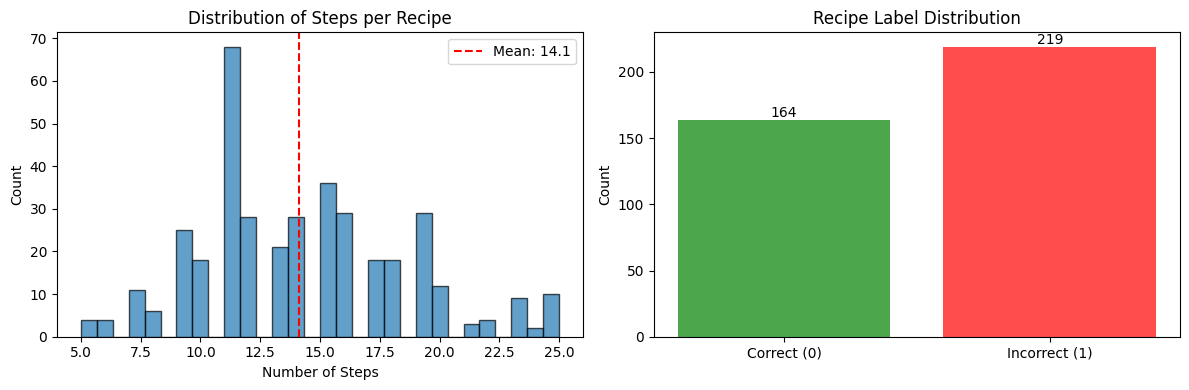


Statistics:
Total recipes: 383
Average steps per recipe: 14.1 ± 4.4
Min/Max steps: 5 / 25


In [25]:
import matplotlib.pyplot as plt

if len(processed_data) == 0:
    print("No data processed! Check feature paths and annotations.")
else:
    # Analyze step distribution
    num_steps_list = [d['num_steps'] for d in processed_data.values()]
    recipe_labels = [d['recipe_label'] for d in processed_data.values()]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Distribution of number of steps per recipe
    axes[0].hist(num_steps_list, bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Number of Steps')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Distribution of Steps per Recipe')
    axes[0].axvline(np.mean(num_steps_list), color='r', linestyle='--', label=f'Mean: {np.mean(num_steps_list):.1f}')
    axes[0].legend()

    # Recipe label distribution
    labels, counts = np.unique(recipe_labels, return_counts=True)
    label_names = ['Correct (0)', 'Incorrect (1)']
    colors = ['green', 'red']

    # Handle case where we might only have one class
    bar_labels = [label_names[int(l)] for l in labels]
    bar_colors = [colors[int(l)] for l in labels]

    axes[1].bar(bar_labels, counts, color=bar_colors, alpha=0.7)
    axes[1].set_ylabel('Count')
    axes[1].set_title('Recipe Label Distribution')
    for i, count in enumerate(counts):
        axes[1].text(i, count + 2, str(count), ha='center')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'step_localization_stats.png'), dpi=150)
    plt.show()

    print(f"\nStatistics:")
    print(f"Total recipes: {len(processed_data)}")
    print(f"Average steps per recipe: {np.mean(num_steps_list):.1f} ± {np.std(num_steps_list):.1f}")
    print(f"Min/Max steps: {min(num_steps_list)} / {max(num_steps_list)}")

## Summary

In this notebook, we completed **Substep 1: Recipe Step Localization**:

1. ✅ Loaded ground truth step annotations
2. ✅ Extracted step boundaries (start, end) for each recipe
3. ✅ Computed step-level embeddings by averaging features within boundaries
4. ✅ Created recipe-level labels (correct/incorrect)
5. ✅ Saved processed data for subsequent substeps

**Next**: Proceed to **Substep 2** - Simple Task-Verification Baselines

---
**Note**: This notebook uses ground truth boundaries as a baseline. For comparison, you can also implement ActionFormer or clustering-based approaches, though the professor mentioned that poor performance is expected for automatic segmentation.